In [ ]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plot
import numpy as np


Change working directory to root folder if needed below:

In [ ]:
# os.chdir(Path.cwd().parent)

In [4]:
os.getcwd()

'c:\\Users\\Tomas\\Desktop\\Thesis Stuff\\Coding'

In [5]:
from src import constants as const
from src.data_cleaning import DataCleaner

In [6]:

vehicle_df = pd.read_csv(const.PATH_TO_RAW_VEHICLE_DATA)

user: 455fc4e611d63fe7bf86c9ecde11f5882d0d2660ba195828652bccda56d369d3
Number of Car Ids: 2162

Count Duplicate Vehicle Ids: 0


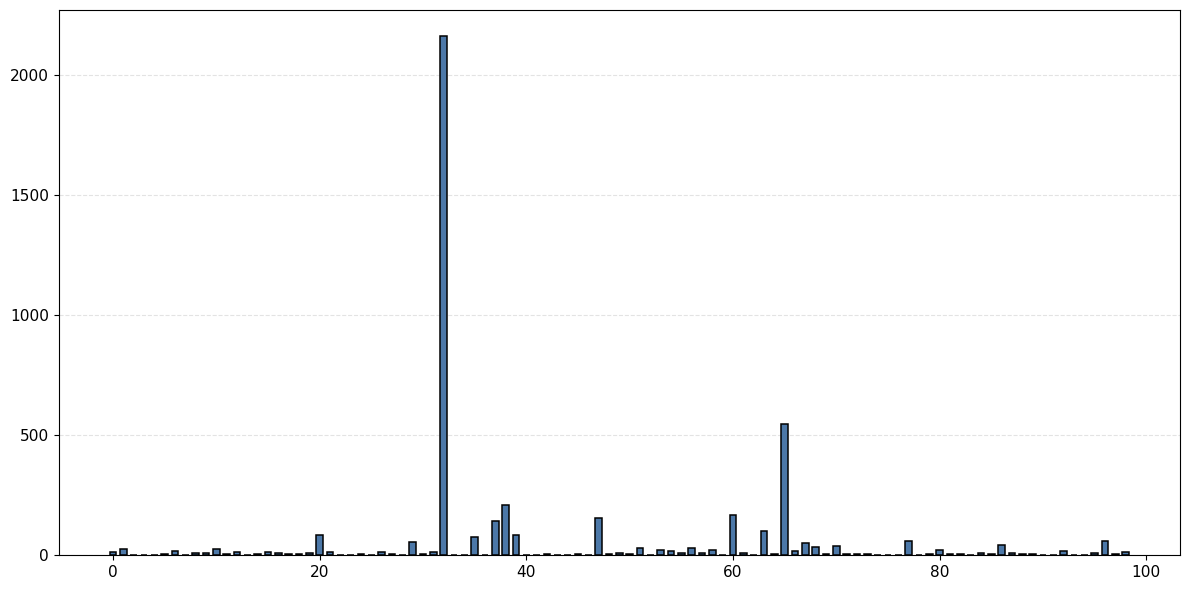

In [7]:
id = vehicle_df["user_id"][3]
mask = vehicle_df["user_id"] == id

print(f"user: {id}",
      f"Number of Car Ids: {len(vehicle_df[mask])}",
      sep="\n")
print()

print(f"Count Duplicate Vehicle Ids: {sum(vehicle_df["vehicle_id"].value_counts() > 1)}")


vehicle_counts = vehicle_df.groupby("user_id")["vehicle_id"].count()


fig, ax = plot.subplots(figsize=(12,6))

ax.bar(x=[i for i in range(0,len(vehicle_counts))],
       height=vehicle_counts,
       color=const.PALETTE["blue"],
      edgecolor="black",
      linewidth=1.1,
      width=0.65)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)
ax.set_axisbelow(True)

plot.xticks(fontsize=11)
plot.yticks(fontsize=11)

plot.tight_layout()
plot.show()

## Notes

1. Each user has multiple vehicles or has put the device into multiple vehicles
2. Each vehicle id is unique and there are no duplicates meaning that no users share the same car
3. There are some users that have >2000 car id's (car service?)

Question: How to deal with mutiple users having multiple car ids, is that even a problem?


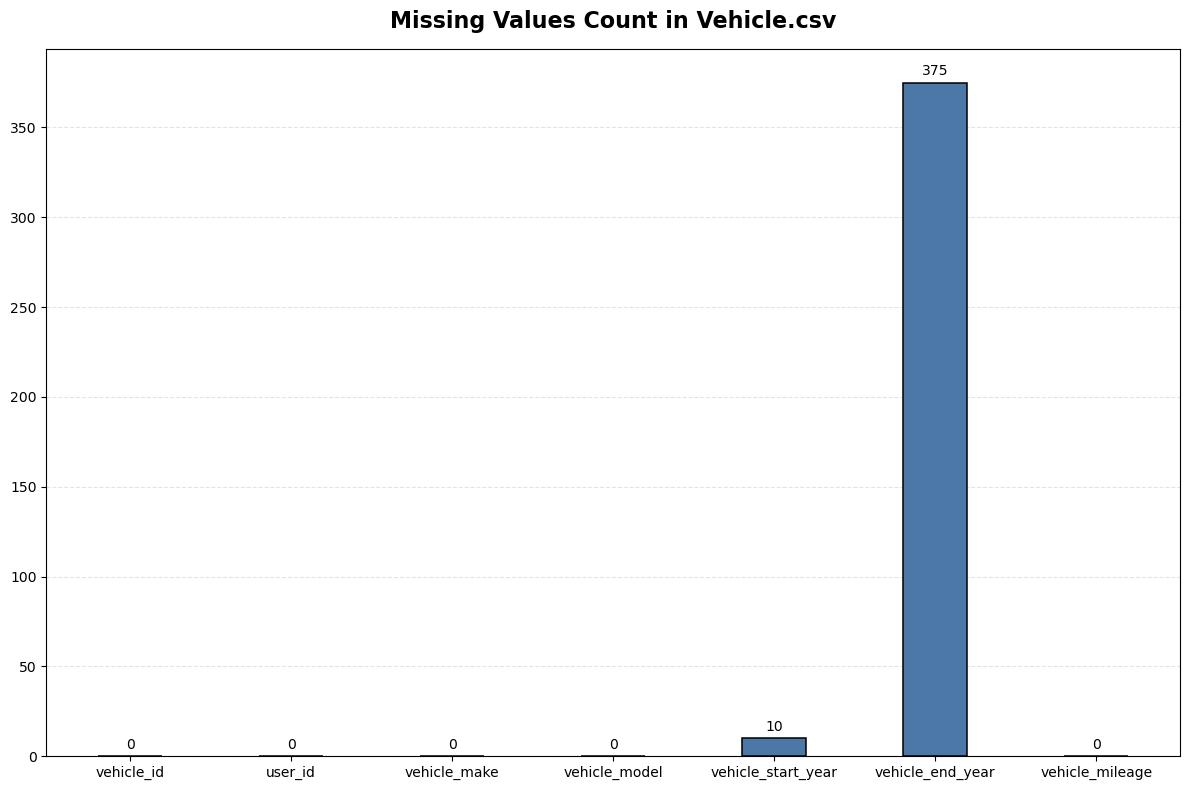

In [8]:
vehicle_df.isna().sum()

fig, ax = plot.subplots(figsize=(12,8))

bars = ax.bar(x=vehicle_df.isna().sum().index, 
        height=vehicle_df.isna().sum(),
        color=const.PALETTE["blue"],
        edgecolor="black",
        linewidth=1.1,
        width=0.4)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.bar_label(bars,
             padding=3)

ax.set_axisbelow(True)

ax.set_title(
    "Missing Values Count in Vehicle.csv",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plot.tight_layout()

In [9]:
vehicle_df.head()

,vehicle_id,user_id,vehicle_make,vehicle_model,vehicle_start_year,vehicle_end_year,vehicle_mileage
0,932e7d163b61aeea7df30df2b3382dd0b3f607e8be19ef...,fc4646682d8e237f659e85719bdb4f89780ca92e4da552...,Audi,A3,2009.0,2014.0,100000-150000
1,9af054c28998604212f6a7d030f49365a8cf757b0066b4...,a96c4380e3747c98a3964804e4765f24be0f726256f132...,Audi,A8,2010.0,2013.0,300000-350000
2,0f5467f72adb05c9af7677d18edf18bd55c08495c170d4...,4fbe8ffbe8f62e67c2956e124841da95c25cffb6144661...,Skoda,Octavia,2020.0,2024.0,50000-100000
3,2ef0f8337f45161d04b8cbd153f217bb171c6f6bfbbf4e...,455fc4e611d63fe7bf86c9ecde11f5882d0d2660ba1958...,Volkswagen,Golf,2012.0,2017.0,0-50000
4,c75cd27c40dd3daacda4ce99679ec82368b7a3ccb44534...,511d5e5cf1baca6d8bf0d1a3ebb42fa059242aaf7d7871...,Porsche,Macan,2014.0,NaN,> 1000000


Questions:
1. How does OBDEleven determine the vehicle end year? 
2. Can we replace vehicle end year with the current calendar year? (because that means that the car isn't discontinued from production)
3. Without start year we lose imporant information on how old the car is, can we remove such rows?